In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time
import joblib
import os
import tempfile

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
from jmetal.algorithm.multiobjective import NSGAII, MOEAD, SPEA2
from jmetal.algorithm.multiobjective.nsgaiii import NSGAIII
from jmetal.operator.crossover import SBXCrossover, DifferentialEvolutionCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.selection import BinaryTournamentSelection
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions
from jmetal.util.comparator import MultiComparator
from jmetal.util.ranking import FastNonDominatedRanking
from jmetal.util.density_estimator import CrowdingDistanceDensityEstimator
from jmetal.core.quality_indicator import HyperVolume
from jmetal.util.aggregation_function import Tschebycheff
from pymoo.indicators.hv import HV

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})

## 1. Data Loading & Exploratory Analysis

In [2]:
DATA_PATH = '../../Datos/Originales/01_Optimizacion/Opt_dataset_4Objectives_CC.csv'
df = pd.read_csv(DATA_PATH)

X_cols = ['x1','x2','x3','x4','x5','x6']
Y_cols = ['y1','y2','y3','y4']
PARAM_NAMES = ['x1 (slot width)','x2 (tooth width ratio)','x3 (slot height)',
               'x4 (magnet thickness)','x5 (pole arc)','x6 (air gap)']
OBJ_NAMES   = ['y1 (Iron Losses [W])','y2 (Torque Ripple)',
               'y3 (neg. Efficiency)','y4 (Total Harmonics)']

X = df[X_cols].values
Y = df[Y_cols].values
BOUNDS_LOW  = df[X_cols].min().values
BOUNDS_HIGH = df[X_cols].max().values

print(f'Dataset: {df.shape[0]} simulations, {df.shape[1]} variables')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()


Dataset: 1700 simulations, 10 variables
Missing values: 0


,x1,x2,x3,x4,x5,x6,y1,y2,y3,y4
0,3.2,0.95,1.2,2.4,46.5,5.1,7.543477,0.000590,-0.809682,0.002764
1,1.2,0.95,1.0,0.1,45.0,4.8,5.377060,0.206311,-0.918555,0.225746
2,1.2,0.75,1.3,0.4,48.0,4.8,5.048992,0.033728,-0.908788,0.060608
3,1.4,0.85,0.8,0.1,49.0,4.7,5.681045,0.238174,-0.917285,0.244254
4,1.2,0.90,2.0,0.1,45.0,4.8,5.177121,0.016478,-0.914834,0.054130


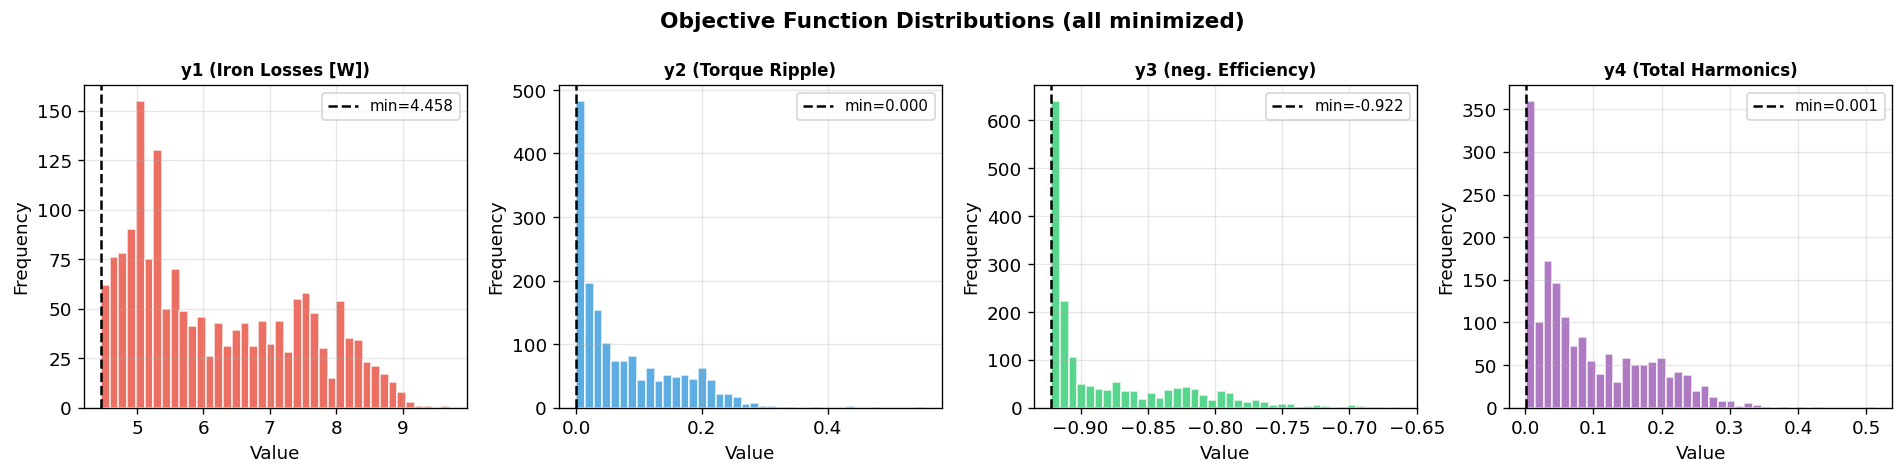

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for ax, col, name, color in zip(axes, Y_cols, OBJ_NAMES, colors):
    ax.hist(df[col], bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
    ax.axvline(df[col].min(), color='black', linestyle='--', linewidth=1.5,
               label=f'min={df[col].min():.3f}')
    ax.legend(fontsize=9)

fig.suptitle('Objective Function Distributions (all minimized)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../Graficos/01_objective_distributions.png', bbox_inches='tight')
plt.show()


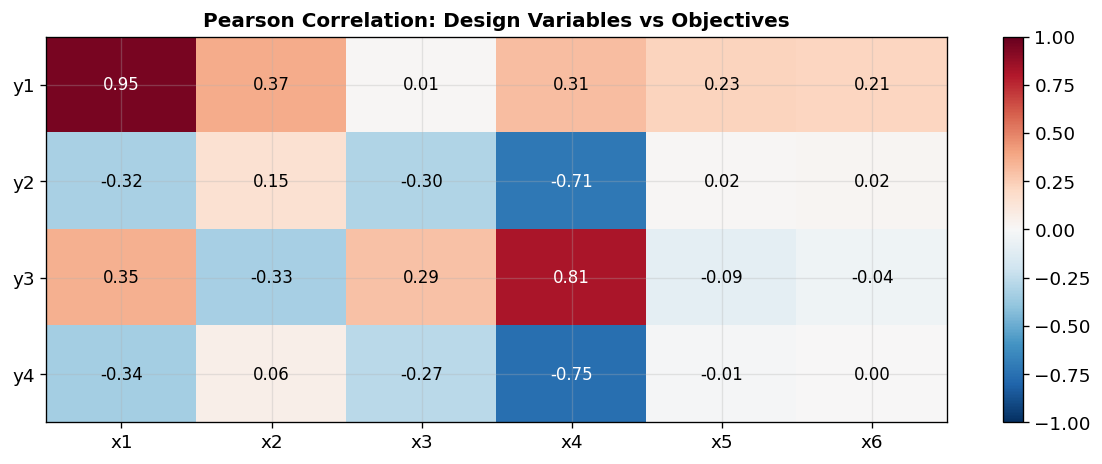

In [ ]:
cross = df.corr().loc[Y_cols, X_cols]
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(cross, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(6)); ax.set_xticklabels([f'x{i+1}' for i in range(6)], fontsize=11)
ax.set_yticks(range(4)); ax.set_yticklabels([f'y{i+1}' for i in range(4)], fontsize=11)
for i in range(4):
    for j in range(6):
        ax.text(j, i, f'{cross.iloc[i,j]:.2f}', ha='center', va='center', fontsize=10,
                color='white' if abs(cross.iloc[i,j]) > 0.5 else 'black')
ax.set_title('Pearson Correlation: Design Variables vs Objectives', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../Graficos/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 2. Surrogate Model


In [35]:
MODEL_PATH = '../../Modelos/modelo_final_35_train.pkl'
surrogate  = joblib.load(MODEL_PATH)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.35, random_state=42)
Y_pred     = surrogate.predict(X_test)
r2_per_obj = r2_score(Y_test, Y_pred, multioutput='raw_values')

print(f'{"Objective":<30s}  {"R²":>8s}')
print('-'*42)
for name, r2 in zip(OBJ_NAMES, r2_per_obj):
    print(f'{name:<30s}  {r2:>8.4f}')
print(f'{"AVERAGE":<30s}  {r2_score(Y_test, Y_pred, multioutput="uniform_average"):>8.4f}')


Objective                             R²
------------------------------------------
y1 (Iron Losses [W])              0.9949
y2 (Torque Ripple)                0.9105
y3 (neg. Efficiency)              0.9659
y4 (Total Harmonics)              0.9361
AVERAGE                           0.9519


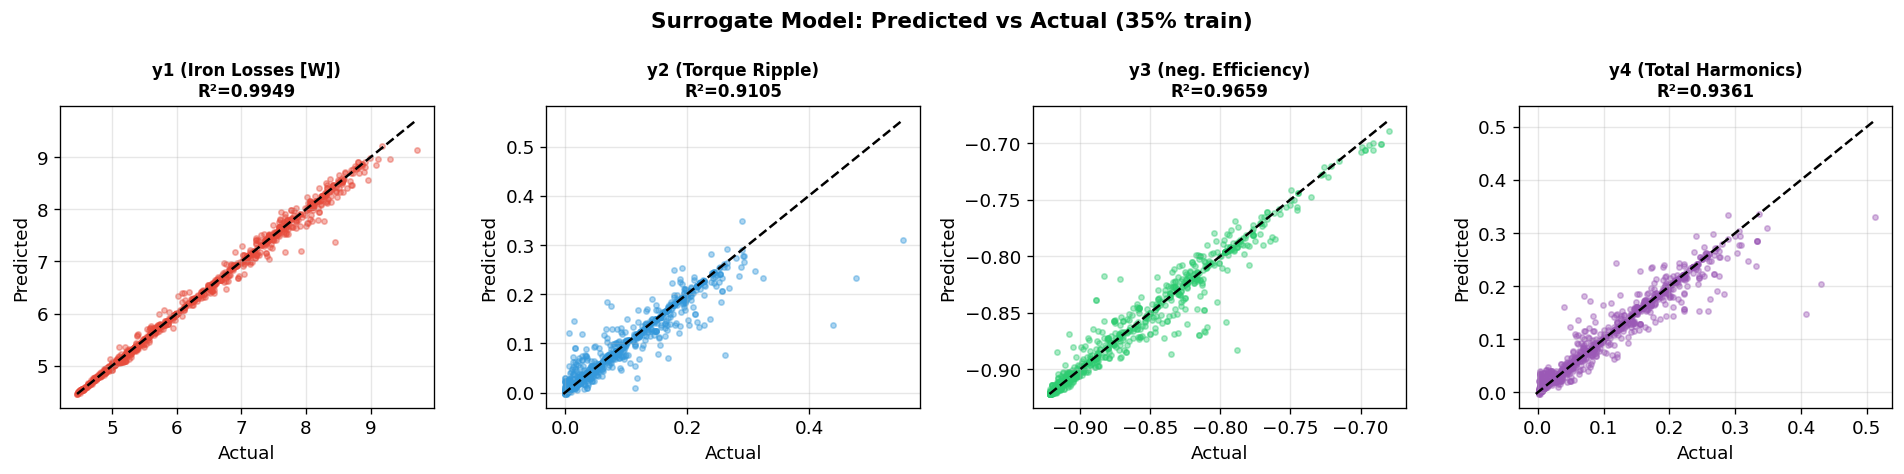

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for i, (ax, name, color) in enumerate(zip(axes, OBJ_NAMES, colors)):
    ax.scatter(Y_test[:, i], Y_pred[:, i], alpha=0.4, s=10, color=color)
    lims = [min(Y_test[:,i].min(), Y_pred[:,i].min()), max(Y_test[:,i].max(), Y_pred[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nR²={r2_per_obj[i]:.4f}', fontsize=10, fontweight='bold')

fig.suptitle('Surrogate Model: Predicted vs Actual (35% train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../Graficos/03_surrogate_quality.png', bbox_inches='tight')
plt.show()


## 3. Problem Definition 


In [ ]:
class MotorDesignProblem(FloatProblem):
    """4-objective motor design problem via surrogate model. All objectives minimized."""
    def __init__(self, surrogate_model, lower_bounds, upper_bounds):
        super().__init__()
        self.surrogate    = surrogate_model
        self.lower_bound  = list(lower_bounds)
        self.upper_bound  = list(upper_bounds)
        self.obj_directions = [self.MINIMIZE] * 4
        self.obj_labels     = ['y1 Iron Losses','y2 Torque Ripple',
                               'y3 neg Efficiency','y4 Total Harmonics']

    def number_of_objectives(self): return 4
    def number_of_constraints(self): return 0

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        x = np.clip(np.array(solution.variables).reshape(1,-1), self.lower_bound, self.upper_bound)
        y = self.surrogate.predict(x)[0]
        for k in range(4):
            solution.objectives[k] = float(y[k])
        return solution

    def name(self): return 'MotorDesignProblem'

def get_front_arrays(algorithm):
    algorithm.run()
    front = get_non_dominated_solutions(algorithm.result())
    return (np.array([s.variables for s in front]),
            np.array([s.objectives for s in front]))

def generate_reference_points(n_obj, n_divisions):
    """Das-Dennis simplex lattice reference points."""
    def _rec(n, total, cur, res):
        if n == 1: res.append(cur + [total]); return
        for i in range(total + 1): _rec(n-1, total-i, cur+[i], res)
    pts = []
    _rec(n_obj, n_divisions, [], pts)
    return np.array(pts, dtype=float) / n_divisions

class ReferenceDirections:
    """Wrapper: NSGAIII expects an object with .compute() method."""
    def __init__(self, arr): self._arr = arr
    def compute(self): return self._arr

def make_weight_file(n_obj=4, n_div=5):
    """Generate MOEAD weight vectors and save to temp .dat file."""
    vecs    = generate_reference_points(n_obj, n_div)
    tmp_dir = tempfile.mkdtemp()
    np.savetxt(os.path.join(tmp_dir, f'W{n_obj}D_{len(vecs)}.dat'), vecs, fmt='%.6f')
    return tmp_dir, len(vecs)

def is_pareto(costs):
    """Boolean mask of non-dominated solutions (minimization)."""
    n = len(costs)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(costs[j] <= costs[i]) and np.any(costs[j] < costs[i]):
                dominated[i] = True; break
    return ~dominated



Problem class and helpers defined.


## 4. Run All Algorithms




In [ ]:
os.makedirs('../../Graficos', exist_ok=True)

N_POP     = 120
N_GEN     = 120
MAX_EVALS = N_POP * N_GEN
N_VARS    = len(BOUNDS_LOW)   # 6

problem = MotorDesignProblem(surrogate, BOUNDS_LOW, BOUNDS_HIGH)

ETA_C = 20   
ETA_M = 20   
P_C   = 0.9  

def make_xover(): return SBXCrossover(probability=P_C, distribution_index=ETA_C)
def make_mut():   return PolynomialMutation(probability=1.0/N_VARS, distribution_index=ETA_M)
def make_sel():
    return BinaryTournamentSelection(
        MultiComparator([FastNonDominatedRanking.get_comparator(),
                         CrowdingDistanceDensityEstimator.get_comparator()]))

# ── NSGA-II
print('Running NSGA-II...', end=' ', flush=True); t0 = time.time()
alg = NSGAII(problem=problem, population_size=N_POP, offspring_population_size=N_POP,
             mutation=make_mut(), crossover=make_xover(), selection=make_sel(),
             termination_criterion=StoppingByEvaluations(MAX_EVALS))
pf_X_nsga2, pf_Y_nsga2 = get_front_arrays(alg)
print(f'{time.time()-t0:.1f}s | Pareto size: {len(pf_X_nsga2)}')

# ── NSGA-III
print('Running NSGA-III...', end=' ', flush=True); t0 = time.time()
alg = NSGAIII(
    reference_directions=ReferenceDirections(generate_reference_points(4, 7)),
    problem=problem,
    population_size=N_POP,          
    mutation=make_mut(),
    crossover=make_xover(),
    termination_criterion=StoppingByEvaluations(MAX_EVALS))  
pf_X_nsga3, pf_Y_nsga3 = get_front_arrays(alg)
print(f'{time.time()-t0:.1f}s | Pareto size: {len(pf_X_nsga3)}')

# ── MOEA/D 
print('Running MOEA/D...', end=' ', flush=True); t0 = time.time()
tmp_dir, n_w = make_weight_file(4, 5)
alg = MOEAD(problem=problem, population_size=n_w, mutation=make_mut(),
            crossover=DifferentialEvolutionCrossover(CR=0.9, F=0.5, K=0.5),
            aggregation_function=Tschebycheff(dimension=4),
            neighbourhood_selection_probability=0.9, max_number_of_replaced_solutions=2,
            neighbor_size=15, weight_files_path=tmp_dir,
            termination_criterion=StoppingByEvaluations(MAX_EVALS))
pf_X_moead, pf_Y_moead = get_front_arrays(alg)
print(f'{time.time()-t0:.1f}s | Pareto size: {len(pf_X_moead)}')



Running NSGA-II... 

[2026-03-12 15:04:11,288] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-12 15:04:11,297] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-12 15:04:11,590] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-12 15:04:11,590] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-12 15:05:00,529] [jmetal.core.algorithm] [DEBUG] Finished!


49.2s | Pareto size: 117
Running NSGA-III... 

[2026-03-12 15:05:00,545] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-12 15:05:00,545] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-12 15:05:00,882] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-12 15:05:00,902] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-12 15:05:47,770] [jmetal.core.algorithm] [DEBUG] Finished!


47.2s | Pareto size: 104
Running MOEA/D... 

[2026-03-12 15:05:47,818] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-12 15:05:47,818] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-12 15:05:47,956] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-12 15:05:47,957] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-12 15:06:35,655] [jmetal.core.algorithm] [DEBUG] Finished!


47.9s | Pareto size: 41


## 5. Algorithm Comparison

Algorithm      Hypervolume   Pareto size
----------------------------------------
NSGA-II             0.3970           117
NSGA-III            0.4140           104
MOEA/D              0.3688            41


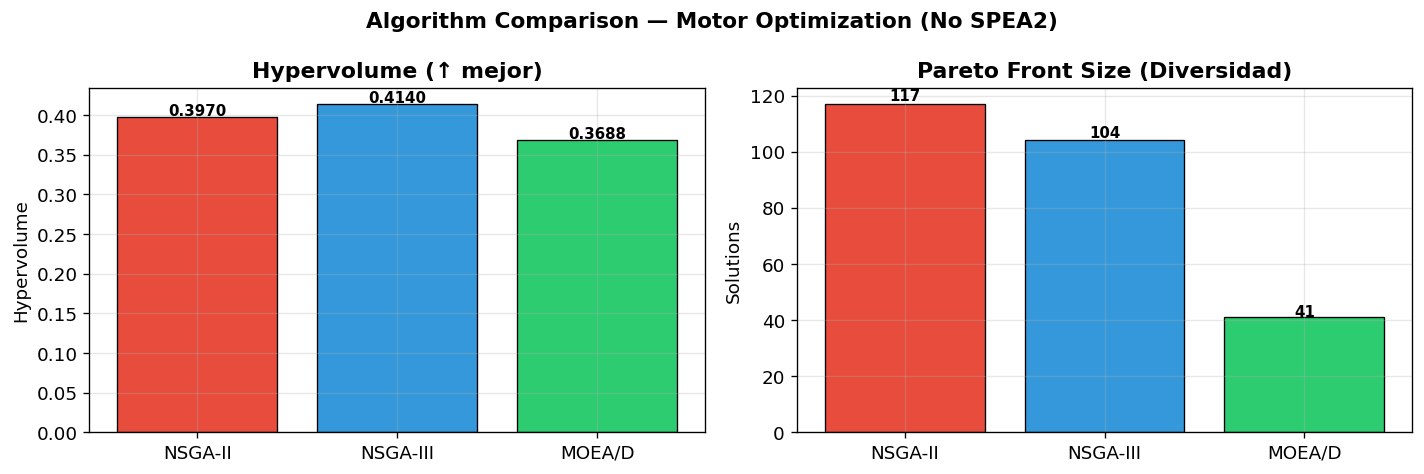

In [ ]:
ref_point = list(Y.max(axis=0) * 1.1)
HV_metric = HyperVolume(ref_point)

results = {}
for name, pf_Y in [('NSGA-II', pf_Y_nsga2), 
                   ('NSGA-III', pf_Y_nsga3),
                   ('MOEA/D',   pf_Y_moead)]:
    results[name] = {'hv': HV_metric.compute(pf_Y), 'size': len(pf_Y)}

print(f'{"Algorithm":<12s}  {"Hypervolume":>12s}  {"Pareto size":>12s}')
print('-'*40)
for name, r in results.items():
    print(f'{name:<12s}  {r["hv"]:>12.4f}  {r["size"]:>12d}')

colors_algo = ['#e74c3c','#3498db','#2ecc71']
algo_names  = list(results.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(algo_names, [results[a]['hv'] for a in algo_names],
            color=colors_algo, edgecolor='black', linewidth=0.8)
axes[0].set_title('Hypervolume (↑ mejor)', fontweight='bold')
axes[0].set_ylabel('Hypervolume')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.005,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(algo_names, [results[a]['size'] for a in algo_names],
            color=colors_algo, edgecolor='black', linewidth=0.8)
axes[1].set_title('Pareto Front Size (Diversidad)', fontweight='bold')
axes[1].set_ylabel('Solutions')
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Algorithm Comparison — Motor Optimization (No SPEA2)', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig('../../Graficos/04_algorithm_comparison_no_spea2.png', bbox_inches='tight')
plt.show()

## 6. NSGA-III 


In [ ]:
hv_indicator = HyperVolume(ref_point)

configs = {
    'η=20 p=0.9 (base)': {'eta': 20, 'p': 0.9, 'gen': 120},
    'η=20 p=0.7':         {'eta': 20, 'p': 0.7, 'gen': 120},
    'η=20 p=1.0':         {'eta': 20, 'p': 1.0, 'gen': 120},
    'η=5  p=0.9':         {'eta':  5, 'p': 0.9, 'gen': 120},
    'η=20 p=0.9 200gen':  {'eta': 20, 'p': 0.9, 'gen': 200},
}

tuning_results2 = {}
for name, cfg in configs.items():
    print(f'Testing {name}...', end=' ', flush=True); t0 = time.time()
    evals = N_POP * cfg['gen']
    alg = NSGAIII(
        reference_directions=ReferenceDirections(generate_reference_points(4, 7)),
        problem=problem,
        population_size=N_POP,
        mutation=PolynomialMutation(probability=1.0/N_VARS, distribution_index=cfg['eta']),
        crossover=SBXCrossover(probability=cfg['p'], distribution_index=cfg['eta']),
        termination_criterion=StoppingByEvaluations(max_evaluations=evals))
    pf_X_t, pf_Y_t = get_front_arrays(alg)
    hv_t = hv_indicator.compute(pf_Y_t)
    tuning_results2[name] = {'hv': hv_t, 'size': len(pf_Y_t),
                              'pf_X': pf_X_t, 'pf_Y': pf_Y_t}
    print(f'{time.time()-t0:.1f}s | HV={hv_t:.4f} | Pareto size={len(pf_Y_t)}')

print(f'\n{"Config":<25s}  {"HV":>8s}  {"Size":>6s}')
print('-'*45)
for k, v in sorted(tuning_results2.items(), key=lambda x: -x[1]["hv"]):
    print(f'{k:<25s}  {v["hv"]:>8.4f}  {v["size"]:>6d}')


Testing η=20 p=0.9 (base)... 

[2026-03-12 15:06:36,720] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...


[2026-03-12 15:06:36,732] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-12 15:06:37,182] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-12 15:06:37,188] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-12 15:07:33,137] [jmetal.core.algorithm] [DEBUG] Finished!


56.5s | HV=0.4153 | Pareto size=107
Testing η=20 p=0.7... 

[2026-03-12 15:07:33,190] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-12 15:07:33,191] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-12 15:07:33,720] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-12 15:07:33,736] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-12 15:08:31,604] [jmetal.core.algorithm] [DEBUG] Finished!


...

50.1s | HV=0.4148 | Pareto size=111
Testing η=5  p=0.9... 

[2026-03-12 15:09:21,734] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-12 15:09:21,741] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-12 15:09:22,083] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-12 15:09:22,090] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-12 15:10:27,446] [jmetal.core.algorithm] [DEBUG] Finished!


65.7s | HV=0.4127 | Pareto size=104
Testing η=20 p=0.9 200gen... 

[2026-03-12 15:10:27,471] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-12 15:10:27,471] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-12 15:10:27,865] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-12 15:10:27,871] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-12 15:11:53,534] [jmetal.core.algorithm] [DEBUG] Finished!


86.1s | HV=0.4099 | Pareto size=103

Config                           HV    Size
---------------------------------------------
η=20 p=0.9 (base)            0.4153     107
η=20 p=1.0                   0.4148     111
η=5  p=0.9                   0.4127     104
η=20 p=0.7                   0.4115     103
η=20 p=0.9 200gen            0.4099     103


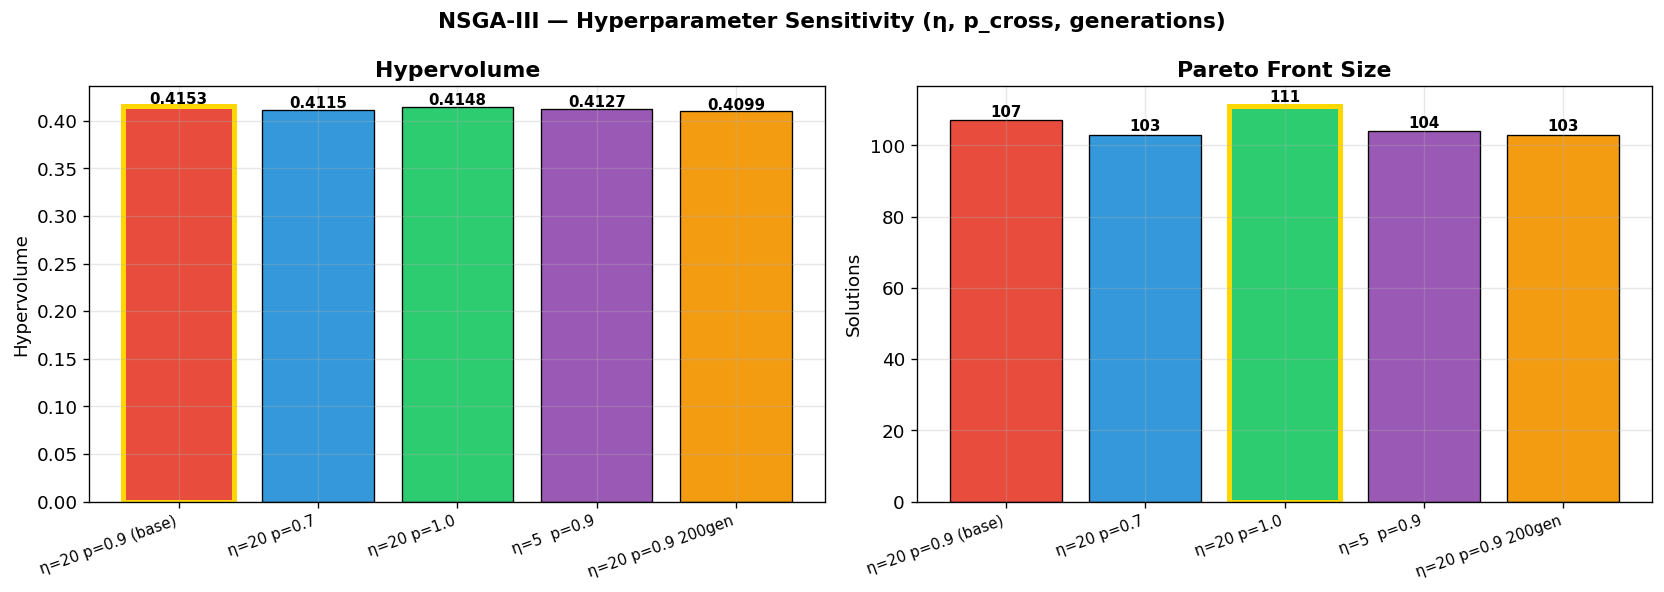


→ Best config: η=20 p=0.9 (base)
  HV=0.4153  |  Pareto size=107


In [41]:
labels2  = list(tuning_results2.keys())
hv_vals2 = [tuning_results2[k]['hv']   for k in labels2]
sz_vals2 = [tuning_results2[k]['size'] for k in labels2]
colors_t2 = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title, ylabel in zip(
        axes,
        [hv_vals2, sz_vals2],
        ['Hypervolume', 'Pareto Front Size'],
        ['Hypervolume', 'Solutions']):
    bars = ax.bar(labels2, vals, color=colors_t2, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    # Highlight best bar with a border
    best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() * (1.005 if title=='Hypervolume' else 1.01),
                f'{bar.get_height():.4f}' if title=='Hypervolume' else str(int(bar.get_height())),
                ha='center', fontsize=9, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)

fig.suptitle('NSGA-III — Hyperparameter Sensitivity (η, p_cross, generations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../Graficos/05_nsga3_tuning.png', bbox_inches='tight')
plt.show()

best_config = max(tuning_results2, key=lambda k: tuning_results2[k]['hv'])
print(f'\n→ Best config: {best_config}')
print(f'  HV={tuning_results2[best_config]["hv"]:.4f}  |  Pareto size={tuning_results2[best_config]["size"]}')

## 7. Best NSGA-III 


In [42]:
best_config = max(tuning_results2, key=lambda k: tuning_results2[k]['hv'])
best_info   = tuning_results2[best_config]

final_X = best_info['pf_X'] 
final_Y = best_info['pf_Y']

print(f'Best configuration : {best_config}')
print(f'Hypervolume        : {best_info["hv"]:.4f}')
print(f'Pareto front size  : {len(final_X)} solutions')


Best configuration : η=20 p=0.9 (base)
Hypervolume        : 0.4153
Pareto front size  : 107 solutions


## 8. 7 Motor Selection 

- **Designs #1–#4:** strict minimum per objective (y1, y2, y3, y4)
- **Design #5:** EV Motor — weights [0.4, 0.1, 0.4, 0.1]
- **Design #6:** Robotics — weights [0.1, 0.4, 0.1, 0.4]
- **Design #7:** Balanced — weights [0.25, 0.25, 0.25, 0.25]

In [43]:
def topsis(obj, w=None):
    if w is None: w = np.ones(obj.shape[1]) / obj.shape[1]
    w = np.array(w) / np.sum(w)
    norms = np.linalg.norm(obj, axis=0); norms[norms==0] = 1.0
    V     = (obj / norms) * w
    d_pos = np.linalg.norm(V - V.min(axis=0), axis=1)
    d_neg = np.linalg.norm(V - V.max(axis=0), axis=1)
    return d_neg / (d_pos + d_neg + 1e-10)

def best_excluding(excl, w):
    mask = np.array([i not in excl for i in range(len(final_Y))])
    return np.where(mask)[0][np.argmax(topsis(final_Y[mask], w))]

i1 = int(np.argmin(final_Y[:, 0]))
i2 = int(np.argmin(final_Y[:, 1]))
i3 = int(np.argmin(final_Y[:, 2]))
i4 = int(np.argmin(final_Y[:, 3]))

excl = {i1, i2, i3, i4}
i5   = best_excluding(excl, [0.4, 0.1, 0.4, 0.1]); excl.add(i5)
i6   = best_excluding(excl, [0.1, 0.4, 0.1, 0.4]); excl.add(i6)
i7   = best_excluding(excl, [0.25, 0.25, 0.25, 0.25])

top7_idx    = np.array([i1, i2, i3, i4, i5, i6, i7])
top7_labels = ['#1 min Iron Losses', '#2 min Torque Ripple', '#3 max Efficiency',
               '#4 min Harmonics',   '#5 EV Motor',          '#6 Robotics Motor',
               '#7 Balanced']
top7_X = final_X[top7_idx]
top7_Y = final_Y[top7_idx]

print(f'\n{"Design":<22s}  {"y1":>8s}  {"y2":>8s}  {"y3":>8s}  {"y4":>8s}')
print('-'*60)
for label, yi in zip(top7_labels, top7_Y):
    print(f'{label:<22s}  {yi[0]:>8.4f}  {yi[1]:>8.4f}  {yi[2]:>8.4f}  {yi[3]:>8.4f}')



Design                        y1        y2        y3        y4
------------------------------------------------------------
#1 min Iron Losses        4.5008    0.0103   -0.7853    0.0267
#2 min Torque Ripple      4.8196   -0.0316   -0.9117    0.0363
#3 max Efficiency         6.1569    0.0037   -0.9215    0.0763
#4 min Harmonics          8.0821   -0.0014   -0.8008   -0.0021
#5 EV Motor               4.7760   -0.0018   -0.8685    0.0176
#6 Robotics Motor         6.9953   -0.0017   -0.7906    0.0033
#7 Balanced               4.8365   -0.0278   -0.9122    0.0521


## 9. Visualizations

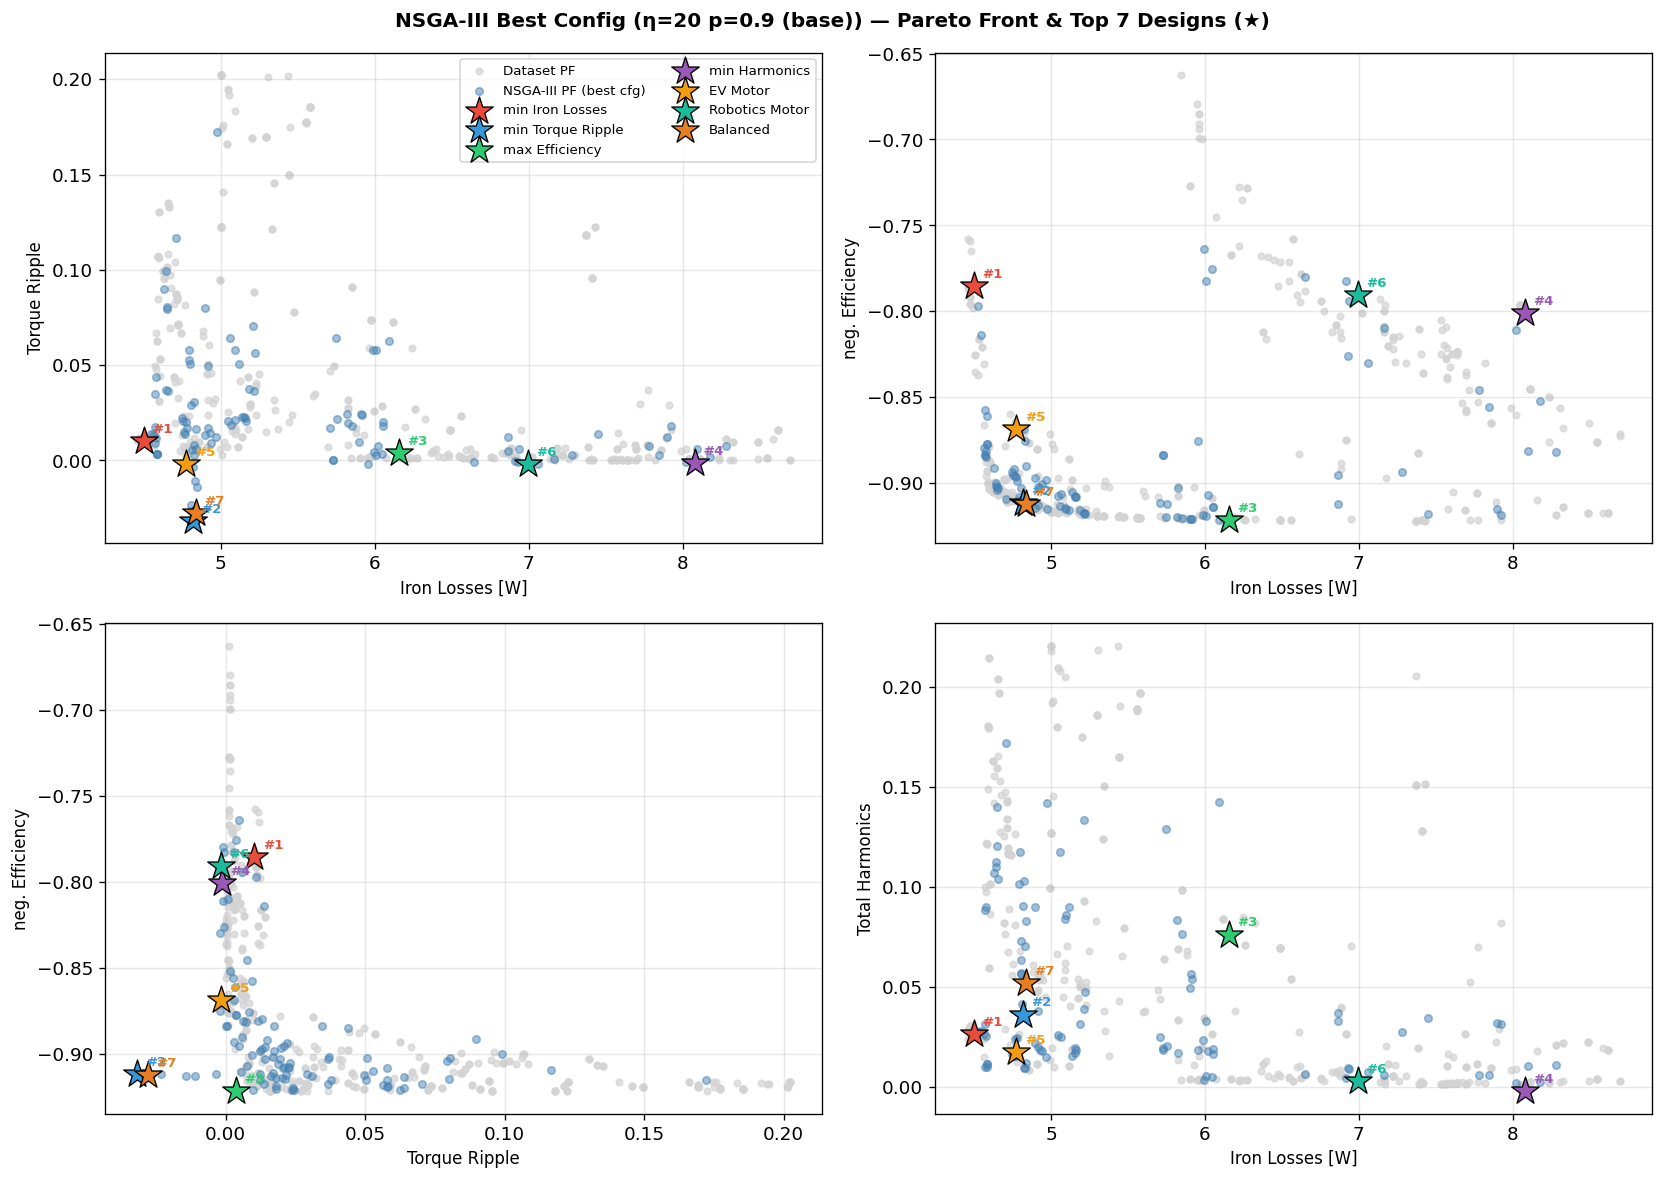

In [44]:
pairs = [(0, 1, 'Iron Losses [W]', 'Torque Ripple'),
         (0, 2, 'Iron Losses [W]', 'neg. Efficiency'),
         (1, 2, 'Torque Ripple',   'neg. Efficiency'),
         (0, 3, 'Iron Losses [W]', 'Total Harmonics')]

colors_top7 = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12','#1abc9c','#e67e22']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pf_dataset = np.where(is_pareto(Y))[0]

for ax, (i, j, xl, yl) in zip(axes, pairs):
    ax.scatter(Y[pf_dataset, i], Y[pf_dataset, j],
               color='lightgray', s=15, zorder=1, label='Dataset PF', alpha=0.7)
    ax.scatter(final_Y[:, i], final_Y[:, j],
               color='steelblue', s=20, zorder=2, alpha=0.5, label='NSGA-III PF (best cfg)')
    for rank, (label, yi, color) in enumerate(zip(top7_labels, top7_Y, colors_top7), 1):
        ax.scatter(yi[i], yi[j], color=color, s=300, zorder=5,
                   marker='*', edgecolors='black', linewidths=0.8,
                   label=label.split(' ', 1)[1])
        ax.annotate(f'#{rank}', xy=(yi[i], yi[j]), xytext=(5, 5),
                    textcoords='offset points', fontsize=8, fontweight='bold',
                    color=color, zorder=6)
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)

axes[0].legend(fontsize=8, loc='upper right', ncol=2)
fig.suptitle(f'NSGA-III Best Config ({best_config}) — Pareto Front & Top 7 Designs (★)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../Graficos/06_pareto_top7.png', bbox_inches='tight')
plt.show()


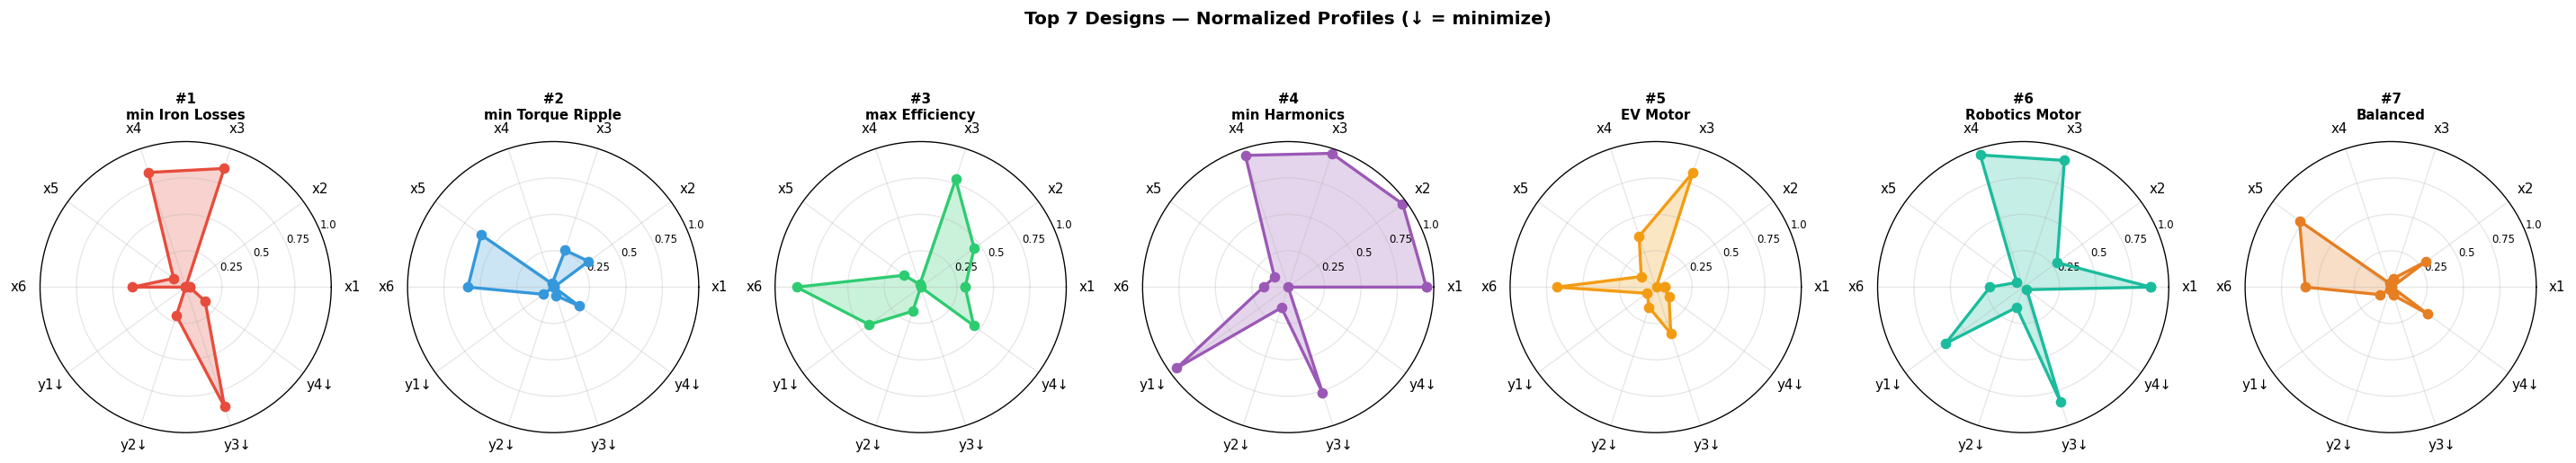

In [45]:
def radar_chart(ax, values, labels, color, alpha=0.25):
    N      = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    v      = values.tolist() + [values[0]]
    a      = angles + [angles[0]]
    ax.plot(a, v, 'o-', color=color, linewidth=2)
    ax.fill(a, v, color=color, alpha=alpha)
    ax.set_xticks(angles); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7)

scaler2 = MinMaxScaler()
scaler2.fit(np.hstack([final_X, final_Y]))
top7_norm = scaler2.transform(np.hstack([top7_X, top7_Y]))

radar_labels = ['x1','x2','x3','x4','x5','x6','y1↓','y2↓','y3↓','y4↓']
fig = plt.figure(figsize=(24, 5))
for i, (nv, color) in enumerate(zip(top7_norm, colors_top7), 1):
    ax = fig.add_subplot(1, 7, i, polar=True)
    radar_chart(ax, nv, radar_labels, color)
    ax.set_title(f'#{i}\n{top7_labels[i-1].split(" ", 1)[1]}',
                 fontweight='bold', fontsize=9, pad=15)

fig.suptitle('Top 7 Designs — Normalized Profiles (↓ = minimize)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../Graficos/07_radar_top7.png', bbox_inches='tight')
plt.show()


## 10. Export Results

In [46]:
rows = []
for label, xi, yi in zip(top7_labels, top7_X, top7_Y):
    row = {'Design': label}
    for k, name in enumerate(['x1','x2','x3','x4','x5','x6']):
        row[name] = round(float(xi[k]), 4)
    for k, name in enumerate(['y1','y2','y3','y4']):
        row[name] = round(float(yi[k]), 6)
    rows.append(row)

df_top7 = pd.DataFrame(rows).set_index('Design')
os.makedirs('../../Datos/Transformados', exist_ok=True)
df_top7.to_csv('../../Datos/Transformados/top7_motor_designs.csv')

df_top7


,x1,x2,x3,x4,x5,x6,y1,y2,y3,y4
Design,,,,,,,,,,
#1 min Iron Losses,1.0833,0.7008,1.8365,2.0606,45.1535,4.2793,4.500800,0.010310,-0.785335,0.026667
#2 min Torque Ripple,1.0182,0.7902,1.1625,0.0648,45.9071,4.7047,4.819570,-0.031647,-0.911709,0.036320
#3 max Efficiency,1.9054,0.8358,1.7469,0.0503,45.2077,5.2171,6.156931,0.003747,-0.921463,0.076282
#4 min Harmonics,3.8075,0.9895,1.9610,2.3671,45.1747,3.9055,8.082094,-0.001400,-0.800816,-0.002053
#5 EV Motor,1.1785,0.7027,1.8042,0.9154,45.1845,4.8855,4.776033,-0.001817,-0.868545,0.017621
#6 Robotics Motor,3.5940,0.7862,1.9026,2.3747,45.0828,4.0173,6.995345,-0.001743,-0.790611,0.003254
#7 Balanced,1.0252,0.7899,0.9299,0.0697,46.1469,4.7062,4.836466,-0.027759,-0.912157,0.052062
